In [30]:
import os
from dotenv import load_dotenv

from langchain_ollama import ChatOllama
from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph, START, END
from typing import TypedDict

load_dotenv()

True

In [31]:
subgraph_llm = ChatOllama(model='gemma4:31b-cloud')
parentgraph_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [32]:
class SubGraphState(TypedDict):

    input_text: str
    translated_text: str

def get_translated(state: SubGraphState):

    prompt = f"""

    Translate the following text to Hindi: \n {state['input_text']}
    Keep it natural and clear, don't add any extra text.""".strip()

    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

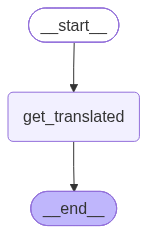

In [33]:
translate_graph = StateGraph(SubGraphState)

translate_graph.add_node('get_translated', get_translated)

translate_graph.add_edge(START, 'get_translated')
translate_graph.add_edge('get_translated', END)

translator = translate_graph.compile()

translator

In [34]:
class ParentGraphState(TypedDict):

    question: str
    answer: str
    translated_texts: str

def get_answer(state: ParentGraphState):

    prompt=f"You're a helpful assistant. Answer clearly within 250 words. \nQuestion: \n{state['question']}"


    answer = parentgraph_llm.invoke(prompt).content

    return {'answer': answer}

def translate_answer(state: ParentGraphState):

    translated_text = translator.invoke({'input_text':state['answer']})

    return {'translated_texts': translated_text}

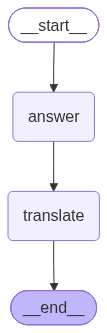

In [35]:
qa_graph = StateGraph(ParentGraphState)

qa_graph.add_node('answer', get_answer)
qa_graph.add_node('translate', translate_answer)

qa_graph.add_edge(START, 'answer')
qa_graph.add_edge('answer', 'translate')
qa_graph.add_edge('translate', END)
qa_chain = qa_graph.compile()

qa_chain

In [36]:
result = qa_chain.invoke({'question': 'What is Force?'})

In [46]:
result.keys()

dict_keys(['question', 'answer', 'translated_texts'])

In [47]:
print(f"Question: {result['question']}\n")
print(f"Answer: {result['answer']}\n")
print(f"Translated Answer: \n\n{result['translated_texts']['translated_text']}\n")

Question: What is Force?

Answer: Force is a fundamental concept in physics, representing any interaction that, when unopposed, will change the motion of an object. It can be described as a push or a pull exerted on an object.

Forces are **vector quantities**, meaning they possess both magnitude (strength) and direction. For example, pushing a box with 10 Newtons of force to the east is distinct from pushing it with 10 Newtons to the north.

When a **net force** acts on an object, it causes the object to accelerate, either by changing its speed, its direction of motion, or both. This principle is famously encapsulated by Newton's Second Law of Motion: F=ma (Force equals mass times acceleration). Forces can also cause objects to deform or change shape, even if they don't cause a noticeable change in motion (e.g., compressing a spring).

Common examples of forces include:
*   **Gravitational force**: The attraction between objects with mass.
*   **Electromagnetic force**: Responsible fo